In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegFileWriter, FuncAnimation

In [2]:
class gaussian:
    def __init__(self, device, dtype):
        self.pos =  -1.0 + 2.0 * torch.rand(2, device=device, dtype=dtype)
        self.alpha = torch.rand((), device=device, dtype=dtype)
        self.color= torch.rand(3, device=device, dtype=dtype)
        self.sigma_x = 0.8*torch.rand((), device=device, dtype=dtype)
        self.sigma_y = 0.8*torch.rand((), device=device, dtype=dtype)
        self.radian = 2.0 * torch.pi * torch.rand((), device=device, dtype=dtype)

In [3]:
def Get_NDC_Points(H, W, device):
    x = torch.arange(W, device=device)
    y = torch.arange(H, device=device)

    Y,X = torch.meshgrid([y,x], indexing="ij")
    Y = torch.flip(Y, dims=[0])

    NDCX = (((X + 0.5) / W) * 2.0) - 1.0
    NDCY = (((Y + 0.5) / H) * 2.0) - 1.0

    P = torch.stack([NDCX, NDCY],dim=-1 )

    return P

def Render_Gaussian_(image, g : gaussian, H, W):
    P = Get_NDC_Points(H,W, g.pos.device)
    P = torch.stack([P[...,0] - g.pos[...,0], P[...,1] - g.pos[...,1]],dim=-1)
    
    c = torch.cos( g.radian)
    s = torch.sin( g.radian)
    
    R = torch.stack([
        torch.stack([c, -s]),
        torch.stack([s,  c])
    ])
    
    inv_sig_x = 1.0 / (1e-8 + ( g.sigma_x* g.sigma_x))
    inv_sig_y = 1.0 / (1e-8 + ( g.sigma_y* g.sigma_y))
    zero_x = torch.zeros_like(inv_sig_x)
    zero_y = torch.zeros_like(inv_sig_y)    

    SSt = torch.stack([
        torch.stack([inv_sig_x, zero_x]),
        torch.stack([zero_y, inv_sig_y])
    ])
    
    inv_sigma = R @ SSt @ R.T

    D = inv_sigma @ P[...,None]
    D = D.reshape((H,W,2))
    gaussian = torch.exp(-0.5 * torch.sum(P * D, dim=-1))
    
    rgbs = ( g.color *  g.alpha) * gaussian[...,None]
    #print(f"rgb shape : {rgbs.shape}")
    #img = torch.zeros((H,W,3),dtype=  g.pos.dtype, device= g.pos.device)

    image[...] += rgbs[...]
    image = torch.clamp(image, 0.0, 1.0)
    return image

def Render_Gaussian(pos, color, sigma_x, sigma_y, radian, alpha, H, W):
    P = Get_NDC_Points(H,W, pos.device)
    P = torch.stack([P[...,0] - pos[...,0], P[...,1] - pos[...,1]],dim=-1)
    
    c = torch.cos(radian)
    s = torch.sin(radian)
    
    R = torch.stack([
        torch.stack([c, -s]),
        torch.stack([s,  c])
    ])
    
    inv_sig_x = 1.0 / (1e-8 + (sigma_x*sigma_x))
    inv_sig_y = 1.0 / (1e-8 + (sigma_y*sigma_y))
    zero_x = torch.zeros_like(inv_sig_x)
    zero_y = torch.zeros_like(inv_sig_y)    

    SSt = torch.stack([
        torch.stack([inv_sig_x, zero_x]),
        torch.stack([zero_y, inv_sig_y])
    ])
    
    inv_sigma = R @ SSt @ R.T

    D = inv_sigma @ P[...,None]
    D = D.reshape((H,W,2))
    g = torch.exp(-0.5 * torch.sum(P * D, dim=-1))
    
    rgbs = (color * alpha) * g[...,None]
    #print(f"rgb shape : {rgbs.shape}")
    img = torch.zeros((H,W,3),dtype= pos.dtype, device=pos.device)

    img[...] = rgbs[...]
    img = torch.clamp(img, 0.0, 1.0)
    return img

In [4]:
device = 'cuda'
dtype = torch.float32

pos = torch.tensor([-0.3,-0.1], device=device, dtype=dtype)
alpha = torch.tensor(1.0, device=device, dtype=dtype)
color= torch.tensor([1.0,1.0,1.0], device=device, dtype=dtype)
sigma_x = torch.tensor(0.1, device=device, dtype=dtype)
sigma_y = torch.tensor(0.3, device=device, dtype=dtype)
init_degree = 30.0
init_rad = np.deg2rad(init_degree)
radian = torch.tensor(init_rad, device=device, dtype=dtype)

target_pos = torch.tensor([0.1,0.1], device=device, dtype=dtype)
target_alpha = torch.tensor(1.0, device=device, dtype=dtype)
target_color= torch.tensor([0.7,0.0,0.8], device=device, dtype=dtype)
target_sigma_x = torch.tensor(0.4, device=device, dtype=dtype)
target_sigma_y = torch.tensor(0.3, device=device, dtype=dtype)

target_degree = -20.0
target_rad = np.deg2rad(target_degree)
target_radian = torch.tensor(target_rad, device=device, dtype=dtype)

H = 96
W = 96
image = Render_Gaussian(pos,color,sigma_x, sigma_y,radian,alpha,H,W)
target_image = Render_Gaussian(target_pos, target_color, target_sigma_x, target_sigma_y, target_radian, target_alpha, H, W)

In [5]:
train_time = 200

p = pos.clone().requires_grad_(True)
a = alpha.clone().requires_grad_(True)
c = color.clone().requires_grad_(True)
s_x = sigma_x.clone().requires_grad_(True)
s_y = sigma_y.clone().requires_grad_(True)
r = radian.clone().requires_grad_(True)

optimizer = torch.optim.Adam([p,a,c,s_x,s_y, r], lr=0.01)
frames=  []

for step in range(train_time):
    optimizer.zero_grad()

    current_step = Render_Gaussian(p,c,s_x, s_y, r, a, H,W)
    loss = torch.mean((target_image - current_step)**2)
    loss.backward()

    optimizer.step()
    frames.append(current_step)

anim_fig, anim_ax = plt.subplots(figsize=(6,6))
anim_ax.set_title('gaussian tranining')
anim_ax.axis('off')
img = anim_ax.imshow(frames[0].cpu().detach().numpy(), vmin=0.0, vmax=1.0, interpolation="nearest")
text = anim_ax.text(0.5,-0.05, f"Iteration : 0", ha = 'center', fontsize=12,transform=anim_ax.transAxes)


def update_anim(idx):
    img.set_array(frames[idx].cpu().detach().numpy())
    text.set_text(f"Iteration : {idx}")

    return [img , text]

fps =30
filename='gauusian_train.mp4'

writer = FFMpegFileWriter(fps=fps,bitrate=1800)
anim = FuncAnimation(anim_fig, update_anim, frames=len(frames), interval=1000/fps, blit=True)

anim.save(filename,writer)

plt.close(anim_fig)


torch.Size([96, 96, 1])


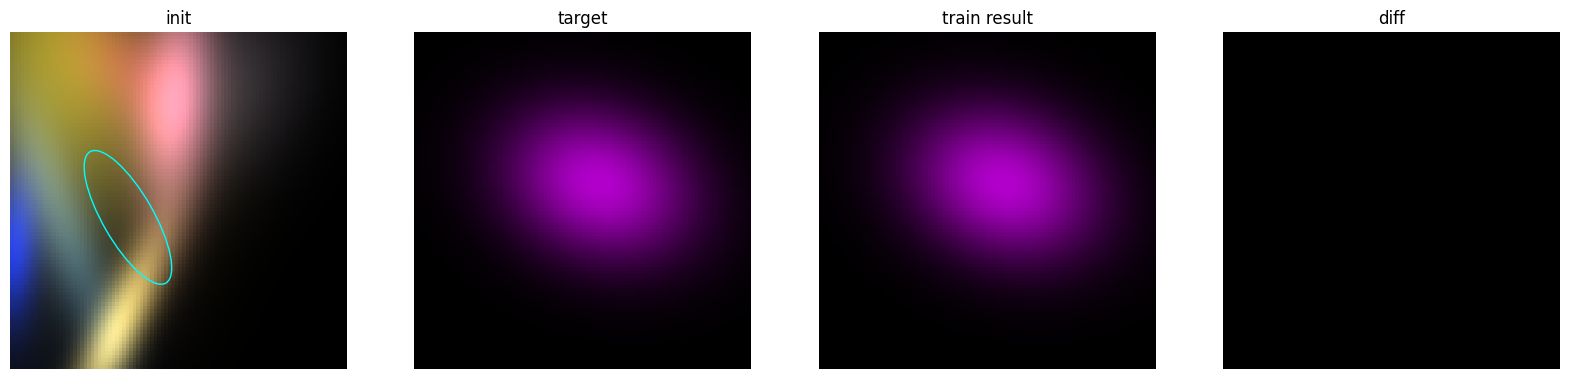

In [9]:
c = 4
fig, ax = plt.subplots(1,c,figsize=(20,5))
for i in range(c):
    ax[i].axis('off')

ax[0].set_title('init')
ax[1].set_title('target')
ax[2].set_title('train result')
ax[3].set_title('diff')

target = target_image.cpu().detach().numpy()
final_train_result = frames[-1]

 
def diff_image(a, b):
    d = torch.abs(a - b)
    d =  0.299 * d[..., 0] + 0.587 * d[..., 1] + 0.114 * d[..., 2]
    gray =  torch.clamp(d, 0.0,1.0)
    gray = gray[...,None]
    return gray

def diff_image2(a, b):
    d = torch.abs(a - b)
    mag = torch.clamp(torch.norm(d, dim=-1, keepdim=True) / np.sqrt(3.0), 0.0, 1.0)
    return mag.repeat(1, 1, 3)

gray = diff_image(target_image, final_train_result)
print(gray.shape)

ax[0].imshow(image.cpu().detach().numpy(), extent=[-1, 1, -1, 1], origin='upper', interpolation="nearest")
ax[1].imshow(target)
ax[2].imshow(final_train_result.cpu().detach().numpy())
ax[3].imshow(gray.cpu().detach().numpy(), cmap='gray', vmin=0.0, vmax=1.0)

from matplotlib.patches import Ellipse
sigma_scale = 3

ellipse = Ellipse(
            (pos[0].cpu().detach().numpy(), pos[1].cpu().detach().numpy()),
            width=sigma_x.cpu().detach().numpy() * sigma_scale,
            height=sigma_y.cpu().detach().numpy() * sigma_scale,
            angle=np.degrees(radian.cpu().detach().numpy()),
            edgecolor='cyan',
            facecolor='none',
            linewidth=1,
            alpha=1.0,
            label='test' ,
            zorder=99
        )
ellipse2 = Ellipse(
            (10.0, 10.0),
            width=1.0,
            height=100,
            angle=np.degrees(-radian.cpu().detach().numpy()),
            edgecolor='cyan',
            facecolor='none',
            linewidth=1,
            alpha=1.0,
            zorder=99
        )
ax[0].add_patch(ellipse)
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1.0,1.0)

plt.show()

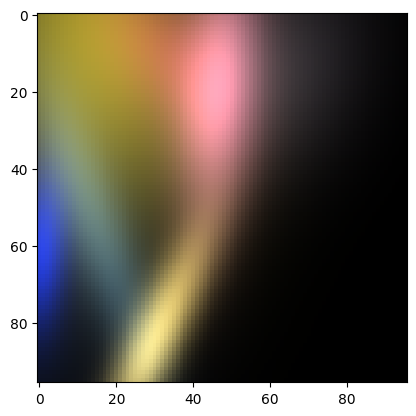

In [7]:
g_count = 8
g_ = []
for i in range(g_count):
    g0 = gaussian(device, dtype)
    g_.append(g0)


image = torch.zeros((H,W,3), device=device, dtype=dtype)
for i in range(g_count):
    image =  Render_Gaussian_(image, g_[i], H, W)

plt.imshow(image.cpu().detach().numpy())
plt.show()


In [8]:
def edge(v0,v1,P):
    return ((P[...,0] - v0[...,0]) *  (v1[...,1] - v0[...,1])) - ((P[...,1] - v0[...,1]) *  (v1[...,0] - v0[...,0]))

def Render_Hard_Edge(vertices, colors, H, W):
    P = Get_NDC_Points(H,W, vertices.device)

    v0, v1, v2 = vertices[0], vertices[1],vertices[2]

    area = edge(v0, v1, v2)
    s = 1.0 if area >=0.0 else -1.0
    area = torch.where(torch.abs(area) < 1e-12, s * torch.tensor(1e-12,device=area.device), area)
    w2 = edge(v0, v1, P) / area
    w0 = edge(v1, v2, P) / area
    w1 = edge(v2, v0, P) / area
    inside = (w0 >= 0) & (w1>= 0.0) & (w2>=0.0)

    img = torch.zeros((H, W, 3), device=vertices.device, dtype=torch.float32)
    rgbs = (w0[...,None] * colors[0] + w1[...,None] * colors[1] + w2[...,None] * colors[2])
    rgbs = torch.clamp(rgbs, 0.0 , 1.0)
    img[inside] = rgbs[inside]

    return img

vertices = torch.tensor([[-0.2, 0.7], 
                         [0.8, -0.1],
                         [-0.6,-0.5]],
                         dtype=dtype, device=device)
colors = torch.tensor([[1.0,0.0,0.0],
                       [0.0,1.0,0.0],
                       [0.0,0.0,1.0]],
                        dtype=dtype, device=device)

target_triangle = Render_Hard_Edge(vertices, colors, H, W)